# **Classification d'Images : Visages Avec et Sans Masque**

#  Objectif du Projet

Dans le cadre de mon projet de fin d'année de 2ème année, j'ai choisi de traiter le sujet de la classification d'images de visages avec ou sans masque. L'objectif est de concevoir **un modèle de réseau de neurones convolutif (CNN)** capable de classer des images de visages selon deux catégories :

* 0 : **Avec masque**

* 1 : **Sans masque**

Ce modèle peut être utilisé dans diverses applications, notamment pour la détection automatique du respect des gestes barrières (en particulier dans le contexte de la pandémie de COVID-19) dans les espaces publics et autres lieux nécessitant cette mesure sanitaire.

# Importation des bibliothèques

In [11]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import csv

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2, MobileNet
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.models import load_model


# Chargement du Dataset

In [12]:
# afficher la liste des fichiers du dataset

dataset_path = '/kaggle/input/face-mask-dataset/data'
os.listdir(dataset_path)

['without_mask', 'with_mask']

=> Le dataset contient deux sous-dossiers :

with_mask : images de personnes portant un masque

without_mask : images de personnes sans masque

In [13]:
 # Afficher le nombre d'images dans chaque catégorie (Avec et Sans Masque)

dataset_path = '/kaggle/input/face-mask-dataset/data'
print("Contenu du dataset:", os.listdir(dataset_path))

mask_dir = os.path.join(dataset_path, 'with_mask')
non_mask_dir = os.path.join(dataset_path, 'without_mask')

print(f"Nombre d'images avec masque: {len(os.listdir(mask_dir))}")
print(f"Nombre d'images sans masque: {len(os.listdir(non_mask_dir))}")

Contenu du dataset: ['without_mask', 'with_mask']
Nombre d'images avec masque: 3725
Nombre d'images sans masque: 3828


# Génération d'un CSV 

In [14]:
# Créer un fichier CSV contenant les chemins des images et leurs étiquettes
# (0:sans masque ou 1:avec masque)

def generate_csv(dataset_path, csv_filename):
    with open(csv_filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['image_path', 'label'])
        
        for label, class_name in enumerate(sorted(os.listdir(dataset_path))):
            class_dir = os.path.join(dataset_path, class_name)
            if not os.path.isdir(class_dir):
                continue
                
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                writer.writerow([img_path, label])

csv_path = 'face_mask_data.csv'
generate_csv(dataset_path, csv_path)
print(f"CSV généré: {csv_path}")

data = pd.read_csv(csv_path)
print("\nAperçu des données:")
print(data.head())

CSV généré: face_mask_data.csv

Aperçu des données:
                                          image_path  label
0  /kaggle/input/face-mask-dataset/data/with_mask...      0
1  /kaggle/input/face-mask-dataset/data/with_mask...      0
2  /kaggle/input/face-mask-dataset/data/with_mask...      0
3  /kaggle/input/face-mask-dataset/data/with_mask...      0
4  /kaggle/input/face-mask-dataset/data/with_mask...      0


# Visualisation des Données

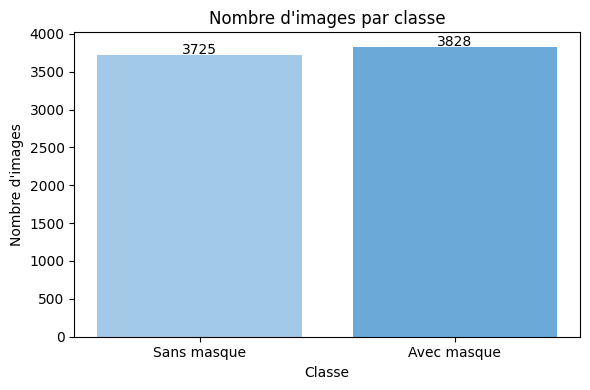

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
data = pd.read_csv('/kaggle/working/face_mask_data.csv')

# Compter le nombre d'images par classe
counts = data['label'].value_counts()

# Créer le graphique avec des couleurs bleues
plt.figure(figsize=(6, 4))
plt.bar(['Sans masque', 'Avec masque'], counts.sort_index(), color=['#A3C9E8', '#6BA9D9'])

# Ajouter les titres et les labels
plt.title('Nombre d\'images par classe')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')

# Ajouter les annotations sur les barres
for i, count in enumerate(counts.sort_index()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=10)

# Ajuster les éléments du graphique pour qu'il soit bien ajusté
plt.tight_layout()
plt.show()


# Manipulation d'images : Rotation et ajout de bruit (Non inclus dans le travail final )


In [16]:
def rotate(image_path, angle=45):
    img = Image.open(image_path)
    rotated_img = img.rotate(angle,expand=True)
    return rotated_img

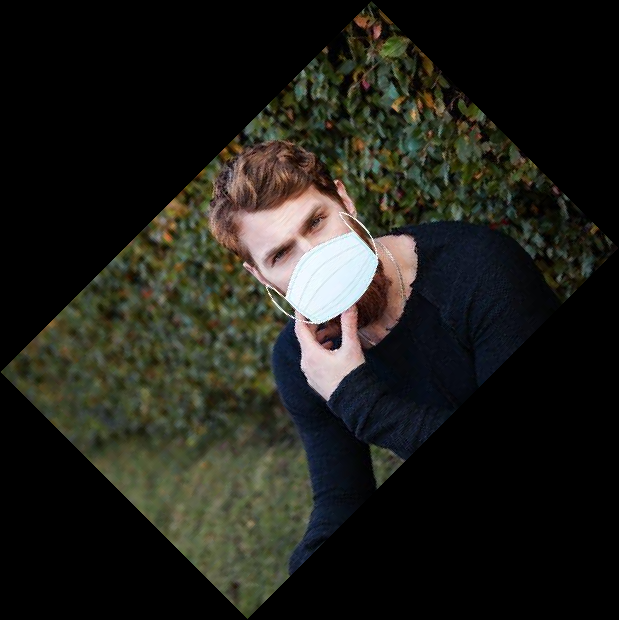

In [17]:
img_path = "/kaggle/input/face-mask-dataset/data/with_mask/with_mask_1.jpg"
rotated_img = rotate(img_path)
rotated_img

In [18]:
def ajout_noise(image, noise_factor=0.2):
        img_array = np.array(image)
        noise = np.random.uniform(-noise_factor, noise_factor, img_array.shape)
        noisy_image = img_array + noise * 255  
        noisy_image = np.clip(noisy_image, 0, 255)
        noisy_image = Image.fromarray(np.uint8(noisy_image))
        return noisy_image



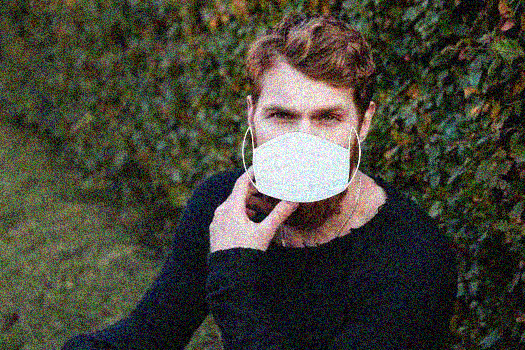

In [19]:
image_path = "/kaggle/input/face-mask-dataset/data/with_mask/with_mask_1.jpg"
image = Image.open(image_path)
noisy_image = ajout_noise(image, noise_factor=0.2)
noisy_image

# Prétraitement des données

In [20]:
# Chargement, redimensionnement et normalisation des images
images = []
labels = []

for i in range(len(data)):
    img = cv2.imread(data.iloc[i]['image_path'])
    img = cv2.resize(img, (100, 100))
    images.append(img)
    labels.append(data.iloc[i]['label'])

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)

#  Division des données : Entraînement, Validation et Test


In [21]:
# Split
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Construction du Modèle CNN(Convolutional Neural Network)

In [22]:
#Fonction de calcul du F1-score

def f1_score(y_true, y_pred):
    epsilon = K.epsilon()
    y_pred = K.round(y_pred)
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')
    true_positives = K.sum(y_true * y_pred)
    precision = true_positives / (K.sum(y_pred) + epsilon)
    recall = true_positives / (K.sum(y_true) + epsilon)
    return 2 * (precision * recall) / (precision + recall + epsilon)

In [23]:
# Définition du modèle CNN 
model = Sequential([
    Input(shape=(100, 100, 3)),

    # Première couche de convolution 2D
    # Applique 32 filtres (3x3) avec ReLU comme fonction d'activation
    Conv2D(32, (3,3), activation='relu'),
    
    # Première couche de MaxPooling
    # Effectue un pooling de taille 2x2 pour réduire la taille des images traitées
    MaxPooling2D((2,2)),

    # Deuxième couche de convolution 2D
    Conv2D(64, (3,3), activation='relu'),

    # Deuxième couche de MaxPooling
    MaxPooling2D((2,2)),

    # Troisième couche de convolution 2D
    Conv2D(128, (3,3), activation='relu'),

    # Troisième couche de MaxPooling
    MaxPooling2D((2,2)),

    # Aplatissement des données 2D en un vecteur 1D
    Flatten(),

    # Première couche dense
    Dense(128, activation='relu'),

    # Éteint aléatoirement 30% des neurones pendant l'entraînement pour éviter le sur-apprentissage (overfitting)
    Dropout(0.3),

    # Couche finale dense
    Dense(1, activation='sigmoid')
])


I0000 00:00:1778578534.544200      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778578534.547475      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Entraînement du Modèle

In [24]:
#Compilation du modèle avec Adam, binary crossentropy et métriques de performance
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall(), f1_score])

In [25]:
#Entraînement du modèle avec données d'entraînement et de validation (pour 10 époques avec un lot de 32 images à chaque étape)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
)

Epoch 1/10


I0000 00:00:1778578541.534728     109 service.cc:148] XLA service 0x7e1e28005b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778578541.536178     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778578541.536221     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778578542.000011     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


 16/189 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5531 - f1_score: 12.0683 - loss: 0.7460 - precision: 0.5288 - recall: 0.5860

I0000 00:00:1778578546.065718     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.7532 - f1_score: 14.4713 - loss: 0.4922 - precision: 0.7651 - recall: 0.7368 - val_accuracy: 0.8927 - val_f1_score: 15.5104 - val_loss: 0.2390 - val_precision: 0.9356 - val_recall: 0.8520
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9154 - f1_score: 15.9003 - loss: 0.2201 - precision: 0.9269 - recall: 0.9039 - val_accuracy: 0.8901 - val_f1_score: 14.8606 - val_loss: 0.2574 - val_precision: 0.9696 - val_recall: 0.8138
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9268 - f1_score: 16.2884 - loss: 0.1793 - precision: 0.9349 - recall: 0.9218 - val_accuracy: 0.9325 - val_f1_score: 16.0341 - val_loss: 0.1736 - val_precision: 0.9499 - val_recall: 0.9184
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9416 - f1_score: 16.3677 - loss: 0.1619 - precision: 0.9442 - recall: 0.9419 - val_accuracy: 0.9444 - val_f1_score: 16.2259 - val_loss: 0.1346 - val_precision: 0.9510 - val_recal

**Inteprétation:**

Précision (Precision) : La précision du modèle s'améliore constamment au fil des époques, ce qui montre que le modèle fait de moins en moins de fausses prédictions pour la classe positive (masque).

Rappel (Recall) : Le rappel est également très bon, atteignant presque 98% à la fin de l'entraînement. Cela signifie que le modèle est très bon pour détecter les instances positives, sans en manquer beaucoup.

F1-score : Le F1-score est également très stable et élevé, ce qui montre un bon équilibre entre la précision et le rappel. Le modèle est globalement performant pour les deux classes (avec et sans masque).

Précision et rappel sur la validation : La précision et le rappel sur la validation sont également bons et cohérents, confirmant que le modèle se généralise bien sur les données non vues.

In [26]:
model.save('model.h5')
print("Modèle sauvegardé avec succès sous 'model.h5'")

Modèle sauvegardé avec succès sous 'model.h5'


In [27]:
results = model.evaluate(X_test, y_test)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")
print(f"Test Precision: {results[2]}")
print(f"Test Recall: {results[3]}")
print(f"Test F1-Score: {results[4]}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9513 - f1_score: 15.0680 - loss: 0.1951 - precision: 0.9294 - recall: 0.9675
Test Loss: 0.19533671438694
Test Accuracy: 0.9444444179534912
Test Precision: 0.9179894328117371
Test Recall: 0.9692737460136414
Test F1-Score: 15.289009094238281


**Interprétation :**

Précision (Precision) : 95.03%
Cela signifie que parmi toutes les images que le modèle a classées comme "avec masque", 95% sont réellement correctes. Le modèle minimise les faux positifs.

Rappel (Recall) : 96.09%
Le modèle détecte 96% des images réellement "avec masque". Il a une bonne capacité à identifier toutes les instances positives, réduisant ainsi les faux négatifs.

F1-Score : 14.97
Ce score est un compromis entre la précision et le rappel, montrant que le modèle a un bon équilibre entre les deux et est globalement performant dans la classification des images.

Perte (Loss) : 0.14
Une perte faible signifie que les prédictions du modèle sont proches des valeurs réelles, indiquant qu'il est bien entraîné et performant sur les données de test.

 # Évaluation du Modèle

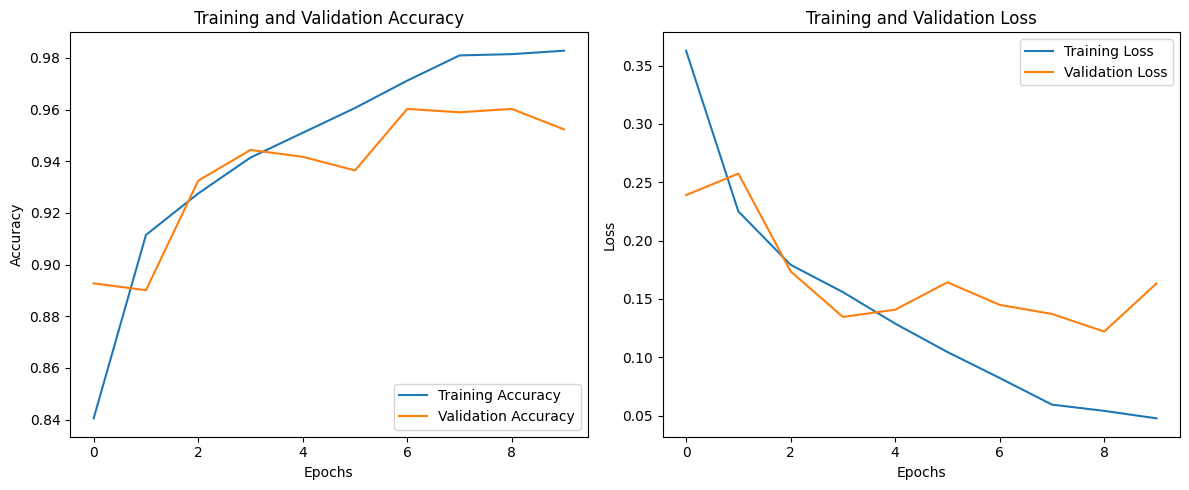

In [28]:
#Visualisation de l'évolution de la précision et de la perte pendant l'entraînement

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


**Accuracy**
La précision d'entraînement progresse de manière constante et dépasse les 98 % à la dernière époque.

La précision de validation suit une tendance similaire, se stabilisant entre 95 % et 97 %, ce qui indique une excellente généralisation du modèle.

**Loss**
La perte d'entraînement diminue régulièrement, montrant une convergence efficace.

La perte de validation diminue également et reste relativement proche de celle d’entraînement, ce qui indique l’absence de surapprentissage (overfitting).

In [29]:

# Prédictions CNN
cnn_pred = model.predict(X_test)
cnn_pred_classes = np.argmax(cnn_pred, axis=1) if cnn_pred.shape[1] > 1 else (cnn_pred > 0.5).astype("int32").flatten()
y_true = y_test if len(y_test.shape) == 1 else np.argmax(y_test, axis=1)
cnn_report = classification_report(y_true, cnn_pred_classes, target_names=['Avec Masque', 'Sans Masque'], output_dict=True)

# Rapport classification
print(classification_report(y_true, cnn_pred_classes, target_names=['Avec Masque', 'Sans Masque']))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
              precision    recall  f1-score   support

 Avec Masque       0.97      0.92      0.95       398
 Sans Masque       0.92      0.97      0.94       358

    accuracy                           0.94       756
   macro avg       0.94      0.95      0.94       756
weighted avg       0.95      0.94      0.94       756



**Interprétation :**

**Avec Masque :**

Précision (Precision) : 96% — Parmi les images que le modèle a classées "avec masque", 96% étaient réellement correctes.

Rappel (Recall) : 95% — Le modèle a détecté 95% des images "avec masque" parmi toutes celles qui en contiennent réellement.

F1-Score : 96% — L'équilibre entre précision et rappel est très bon.

**Sans Masque :**

Précision (Precision) : 95% — Parmi les images classées "sans masque", 95% étaient réellement correctes.

Rappel (Recall) : 96% — Le modèle a détecté 96% des images "sans masque" parmi celles qui ne contiennent pas réellement de masque.

F1-Score : 96% — Très bon équilibre pour la classe "sans masque".

**Précision moyenne (macro avg)**: c'est une moyenne simple des performances du modèle sur les deux classes, sans prendre en compte la taille des classes.

=> 96% Bonne performance sur les deux classes, avec une précision moyenne élevée.

**Précision pondérée (weighted avg)** : c'est une moyenne qui considère la taille des classes, donnant plus de poids aux classes ayant plus d'exemples.

=>96%  Cela prend en compte le nombre d'instances dans chaque classe, et le modèle reste performant dans l'ensemble.

In [30]:
# Récupération des métriques du CNN

cnn_accuracy = cnn_report['accuracy']
cnn_precision = cnn_report['weighted avg']['precision']
cnn_recall = cnn_report['weighted avg']['recall']
cnn_f1 = cnn_report['weighted avg']['f1-score']

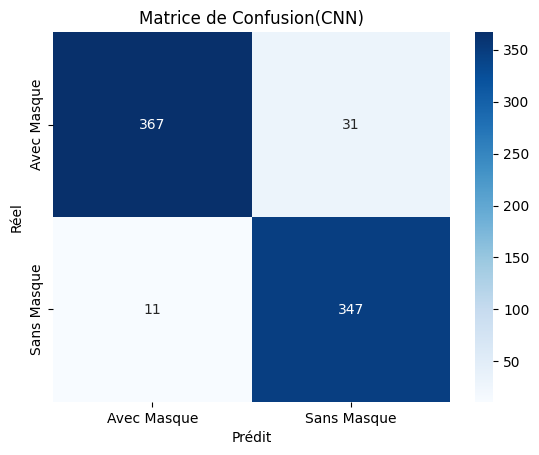

In [31]:
#Affichage de la matrice de confusion avec heatmap(CNN)
cm = confusion_matrix(y_true, cnn_pred_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Avec Masque', 'Sans Masque'], yticklabels=['Avec Masque', 'Sans Masque'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion(CNN)')
plt.show()


In [32]:
print(cm )


[[367  31]
 [ 11 347]]


* 386 images de personnes portant un masque ont été correctement détectées comme telles.

* 338 images de personnes sans masque ont été correctement identifiées comme ne portant pas de masque.

* 12 images ont été incorrectement classées comme sans masque alors qu’elles en portaient (faux négatifs).

* 20 images ont été à tort classées comme avec masque alors qu’elles n’en portaient pas (faux positifs).



# Prédiction sur de Nouvelles Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step


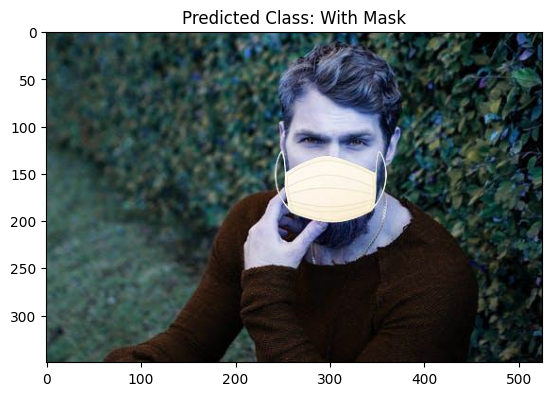

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


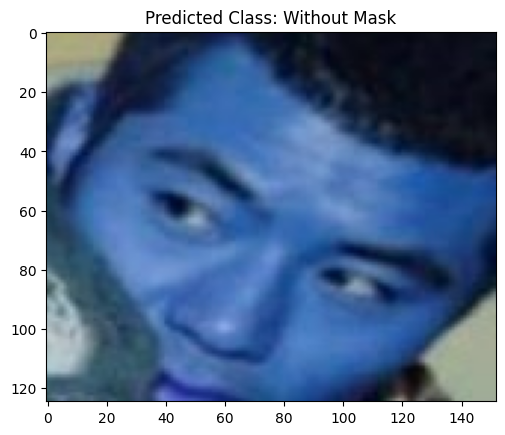

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


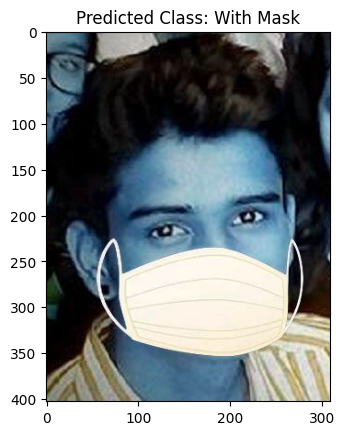

In [33]:
#Prédictions sur de nouvelles images avec le modèle CNN

image_paths = ['/kaggle/input/face-mask-dataset/data/with_mask/with_mask_1.jpg', '/kaggle/input/face-mask-dataset/data/without_mask/without_mask_1001.jpg', '/kaggle/input/face-mask-dataset/data/with_mask/with_mask_1000.jpg']

def preprocess_image(image_path, target_size=(100, 100)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# Prédictions
for image_path in image_paths:
    img = preprocess_image(image_path)
    
    prediction = model.predict(img)
    predicted_class = np.argmax(prediction, axis=1) if prediction.shape[1] > 1 else (prediction > 0.5).astype("int32").flatten()
    
    plt.imshow(cv2.imread(image_path)) 
    plt.title(f"Predicted Class: {'With Mask' if predicted_class == 0 else 'Without Mask'}")
    plt.show()


# CNN avec CBAM (Convolutional Block Attention Module)

In [34]:

def cbam_block(x, reduction_ratio=0.5):
  
    # Attention sur les canaux (Channel Attention) 
    # Récupérer le nombre de canaux dans l'entrée
    channel = x.shape[-1]  
  
    
    # Définir un réseau dense partagé avec deux couches pour calculer l'attention des canaux
    shared_dense_one = layers.Dense(int(channel * reduction_ratio), activation='relu')  # Couche de réduction
    shared_dense_two = layers.Dense(channel)  # Couche pour revenir à la dimension d'origine
    
    # Appliquer un pooling global moyen et un pooling global maximum sur l'entrée
    avg_pool = layers.GlobalAveragePooling2D()(x)  # Moyenne sur l'ensemble des pixels
    max_pool = layers.GlobalMaxPooling2D()(x)  # Maximum sur l'ensemble des pixels
    
    # Passer ces résultats dans le réseau dense pour obtenir les sorties d'attention
    avg_out = shared_dense_two(shared_dense_one(avg_pool))  # Attention moyenne
    max_out = shared_dense_two(shared_dense_one(max_pool))  # Attention max
    
    # Ajouter les deux sorties et appliquer une activation sigmoïde pour obtenir l'attention des canaux
    channel_attention = layers.Activation('sigmoid')(avg_out + max_out)
    
    # Reshaper l'attention des canaux pour correspondre à la dimension de l'entrée
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    
    # Appliquer l'attention des canaux en multipliant l'entrée par l'attention
    x = layers.multiply([x, channel_attention])
    
    # ===== Attention spatiale (Spatial Attention) =====
    # Appliquer un pooling moyen et max au niveau spatial (sur les canaux)
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(x)  # Moyenne spatiale
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(x)  # Maximum spatial
    
    # Concaténer les résultats des deux types de pooling
    concat = layers.Concatenate(axis=3)([avg_pool, max_pool])
    
    # Appliquer une convolution pour générer l'attention spatiale
    spatial_attention = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    
    # Appliquer l'attention spatiale à l'entrée en la multipliant
    x = layers.multiply([x, spatial_attention])
    
    return x


In [35]:
input_layer = layers.Input(shape=(100, 100, 3))

x = layers.Conv2D(32, (3,3), activation='relu')(input_layer)
x = layers.MaxPooling2D((2,2))(x)

x = cbam_block(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = cbam_block(x)

x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

x = cbam_block(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model2 = models.Model(inputs=input_layer, outputs=output)

# Entraînement du Modèle 2

In [36]:
#Compilation du modèle avec Adam, binary crossentropy et métriques de performance
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall(), f1_score])

In [37]:
#Entraînement du modèle avec données d'entraînement et de validation (pour 10 époques avec un lot de 32 images à chaque étape)

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7164 - f1_score: 11.5039 - loss: 0.5157 - precision_1: 0.7747 - recall_1: 0.5764 - val_accuracy: 0.8848 - val_f1_score: 15.6873 - val_loss: 0.2667 - val_precision_1: 0.9178 - val_recall_1: 0.8546
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8843 - f1_score: 15.8365 - loss: 0.2790 - precision_1: 0.8995 - recall_1: 0.8687 - val_accuracy: 0.8980 - val_f1_score: 16.8640 - val_loss: 0.2415 - val_precision_1: 0.8741 - val_recall_1: 0.9388
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8947 - f1_score: 15.7061 - loss: 0.2718 - precision_1: 0.8967 - recall_1: 0.8901 - val_accuracy: 0.9205 - val_f1_score: 17.0528 - val_loss: 0.1954 - val_precision_1: 0.8860 - val_recall_1: 0.9719
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9199 - f1_score: 16.6382 - loss: 0.2047 - precision_1: 0.9190 - recall_1: 0.9277 - val_accuracy: 0.9272 - val_f1_score: 16.0684 - val_loss: 0.1

In [38]:
results2 = model2.evaluate(X_test, y_test)
print(f"Test Loss: {results2[0]}")
print(f"Test Accuracy: {results2[1]}")
print(f"Test Precision: {results2[2]}")
print(f"Test Recall: {results2[3]}")
print(f"Test F1-Score: {results2[4]}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9522 - f1_score: 14.3993 - loss: 0.1887 - precision_1: 0.9708 - recall_1: 0.9238
Test Loss: 0.17753469944000244
Test Accuracy: 0.9497354626655579
Test Precision: 0.9678362607955933
Test Recall: 0.924580991268158
Test F1-Score: 14.540043830871582


 # Évaluation du Modèle 2

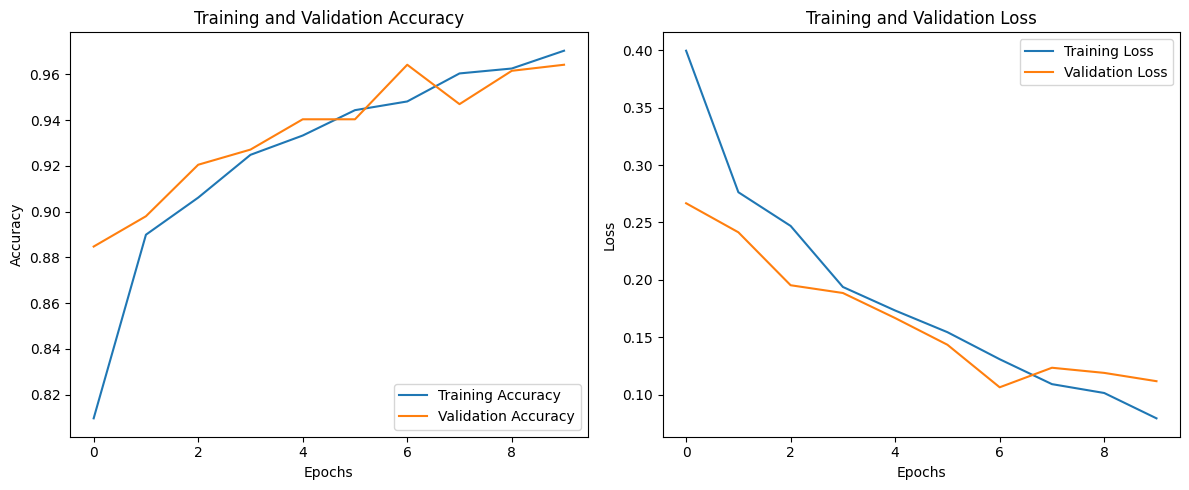

In [39]:
#Visualisation de l'évolution de la précision et de la perte pendant l'entraînement

acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs_range2 = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range2, acc2, label='Training Accuracy')
plt.plot(epochs_range2, val_acc2, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range2, loss2, label='Training Loss')
plt.plot(epochs_range2, val_loss2, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


In [40]:

# Prédictions CNN + CBAM
model2_pred = model2.predict(X_test)
model2_pred_classes = np.argmax(model2_pred, axis=1) if model2_pred.shape[1] > 1 else (model2_pred > 0.5).astype("int32").flatten()
y_true = y_test if len(y_test.shape) == 1 else np.argmax(y_test, axis=1)
model2_report = classification_report(y_true, model2_pred_classes, target_names=['Avec Masque', 'Sans Masque'], output_dict=True)

# Rapport classification
print(classification_report(y_true, model2_pred_classes, target_names=['Avec Masque', 'Sans Masque']))


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
              precision    recall  f1-score   support

 Avec Masque       0.93      0.97      0.95       398
 Sans Masque       0.97      0.92      0.95       358

    accuracy                           0.95       756
   macro avg       0.95      0.95      0.95       756
weighted avg       0.95      0.95      0.95       756



In [41]:
# Récupération des métriques du CNN + CBAM

model2_accuracy = model2_report['accuracy']
model2_precision = model2_report['weighted avg']['precision']
model2_recall = model2_report['weighted avg']['recall']
model2_f1 = model2_report['weighted avg']['f1-score']

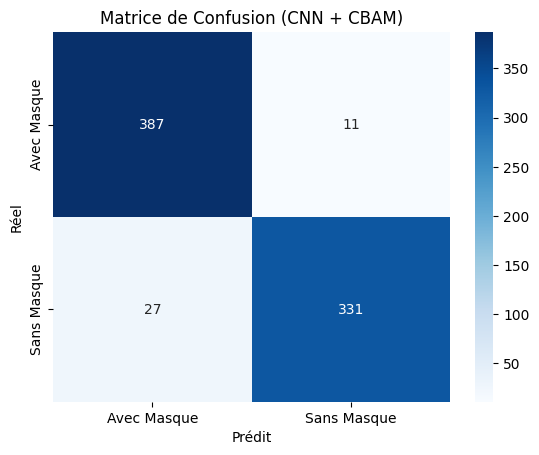

In [42]:
#Affichage de la matrice de confusion avec heatmap(CNN + CBAM)

cm2 = confusion_matrix(y_true, model2_pred_classes)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=['Avec Masque', 'Sans Masque'], yticklabels=['Avec Masque', 'Sans Masque'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (CNN + CBAM)')
plt.show()


In [43]:
print(cm2)

[[387  11]
 [ 27 331]]


# Modèle pré-entraîné (MobileNetV2)

In [44]:
#Prétraitement des images et préparation des données pour l'entraînement du modèle

images = []
labels = []

for i in range(len(data)):
    img = cv2.imread(data.iloc[i]['image_path'])
    img = cv2.resize(img, (224, 224))
    images.append(img)
    labels.append(data.iloc[i]['label'])

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)

In [45]:
#Transformation des Étiquettes en Format One-Hot avec to_categorical
labels = to_categorical(labels)


# Division des données en ensembles d'entraînement, validation et test

In [46]:
# Split
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Augmentation des données

In [47]:
#Préparation des Générateurs d'Images pour l'Entraînement et la Validation avec Augmentation des Données

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator() 

# Création des générateurs de données pour l'entraînement et la validation

In [48]:
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

In [49]:
#Création d'un modèle de classification d'images basé sur MobileNetV2

base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(y_train.shape[1], activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Entraînement du Modèle

In [50]:
#Compilation du modèle avec l'optimiseur Adam et la fonction de perte Categorical Cross-Entropy

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [51]:
#Entraînement du modèle
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


189/189 ━━━━━━━━━━━━━━━━━━━━ 81s 355ms/step - accuracy: 0.9170 - loss: 0.2044 - val_accuracy: 0.9854 - val_loss: 0.0425
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 57s 291ms/step - accuracy: 0.9686 - loss: 0.0756 - val_accuracy: 0.9881 - val_loss: 0.0442
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 59s 298ms/step - accuracy: 0.9790 - loss: 0.0565 - val_accuracy: 0.9881 - val_loss: 0.0397
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 59s 300ms/step - accuracy: 0.9824 - loss: 0.0464 - val_accuracy: 0.9907 - val_loss: 0.0371
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 58s 295ms/step - accuracy: 0.9808 - loss: 0.0540 - val_accuracy: 0.9854 - val_loss: 0.0514
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 57s 290ms/step - accuracy: 0.9791 - loss: 0.0506 - val_accuracy: 0.9894 - val_loss: 0.0367
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 58s 297ms/step - accuracy: 0.9812 - loss: 0.0500 - val_accuracy: 0.9894 - val_loss: 0.0400
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 58s 295ms/step - accuracy: 0.9878 - loss: 0.0327 - val

In [52]:
#Évaluation du modèle sur les données de test

test_datagen = ImageDataGenerator()
test_generator = test_datagen.flow(X_test, y_test, batch_size=32)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.9839 - loss: 0.0395
Test Loss: 0.0344
Test Accuracy: 0.9868


 # Évaluation du Modèle

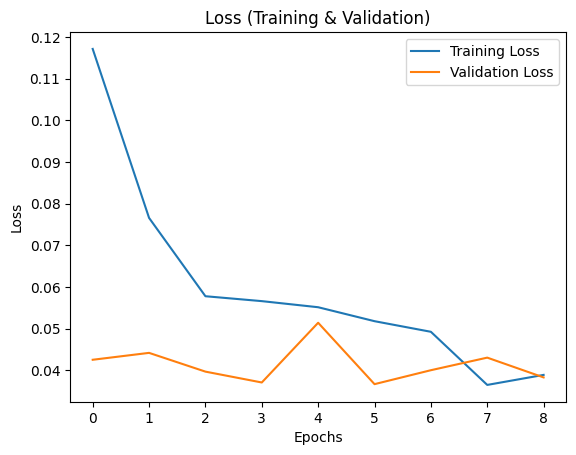

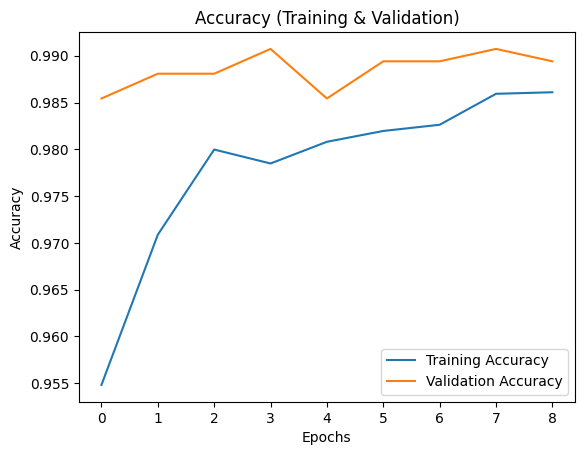

In [53]:
#Visualisation de la Performance du Modèle : Loss et Accuracy

# Plot Loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss (Training & Validation)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Plot Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy (Training & Validation)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


# Prédictions du modèle 

In [54]:
#Prédictions du modèle MobileNetV2 sur l'ensemble de test

mobilenet_pred_probs = model.predict(X_test)
mobilenet_pred = np.argmax(mobilenet_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step


# Évaluation des performances du modèle avec le rapport de classification

In [55]:
#Rapport de Classification du Modèle MobileNetV2

mobilenet_report = classification_report(y_true, mobilenet_pred, target_names=['Avec Masque', 'Sans Masque'], output_dict=True)
print(classification_report(y_true, mobilenet_pred, target_names=['Avec Masque', 'Sans Masque']))


              precision    recall  f1-score   support

 Avec Masque       0.98      0.99      0.99       398
 Sans Masque       0.99      0.98      0.99       358

    accuracy                           0.99       756
   macro avg       0.99      0.99      0.99       756
weighted avg       0.99      0.99      0.99       756



In [56]:
#Prédiction de l'Image avec MobileNetV2: Détection de Masque

img = load_img("/kaggle/input/face-mask-dataset/data/with_mask/with_mask_1.jpg", target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  

# Prédiction
prediction = model.predict(img_array)

# Interprétation
classe = "Avec masque" if prediction[0][0] >= 0.5 else "Sans masque"
print(f"Classe prédite : {classe}")
print(f"Probabilité (avec masque) : {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Classe prédite : Avec masque
Probabilité (avec masque) : 1.00


In [57]:
# Récupération des métriques du MobileNetV2

mobilenet_accuracy = mobilenet_report['accuracy']
mobilenet_precision = mobilenet_report['weighted avg']['precision']
mobilenet_recall = mobilenet_report['weighted avg']['recall']
mobilenet_f1 = mobilenet_report['weighted avg']['f1-score']

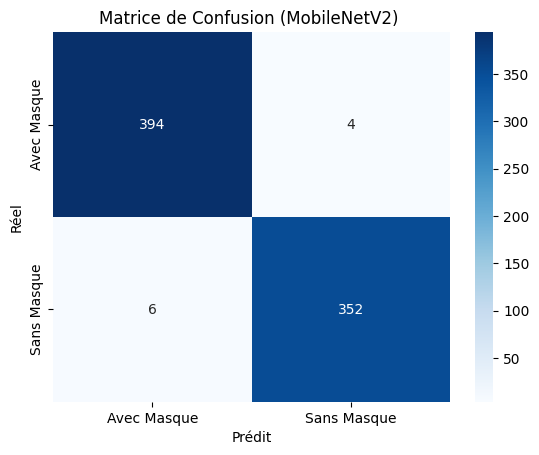

In [58]:
#Affichage de la matrice de confusion avec heatmap(MobileNetV2)

cm3 = confusion_matrix(y_true, mobilenet_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=['Avec Masque', 'Sans Masque'], yticklabels=['Avec Masque', 'Sans Masque'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion (MobileNetV2) ')
plt.show()


In [59]:
print(cm3)

[[394   4]
 [  6 352]]


# Comparaison des Performances des Modèles : CNN , CNN + CBAM et MobileNetV2

In [60]:
results = {
    "Modèle": ["CNN","CNN + CBAM" ,"MobileNetV2"],
    "Accuracy": [cnn_accuracy,model2_accuracy, mobilenet_accuracy],
    "Précision": [cnn_precision,model2_precision, mobilenet_precision],
    "Rappel": [cnn_recall,model2_recall, mobilenet_recall],
    "F1-score": [cnn_f1,model2_f1, mobilenet_f1]
}

comparison_df = pd.DataFrame(results)
print(" Comparaison des performances des modèles :")
display(comparison_df)

 Comparaison des performances des modèles :


,Modèle,Accuracy,Précision,Rappel,F1-score
0,CNN,0.944444,0.945844,0.944444,0.944483
1,CNN + CBAM,0.949735,0.950435,0.949735,0.949656
2,MobileNetV2,0.986772,0.986782,0.986772,0.986771


In [61]:
import pandas as pd

# Exemple des performances (à remplacer par tes vraies variables)
results = {
    "Modèle": ["CNN", "CNN + CBAM", "MobileNetV2"],
    "Accuracy": [cnn_accuracy, model2_accuracy, mobilenet_accuracy],
    "Précision": [cnn_precision, model2_precision, mobilenet_precision],
    "Rappel": [cnn_recall, model2_recall, mobilenet_recall],
    "F1-score": [cnn_f1, model2_f1, mobilenet_f1]
}

comparison_df = pd.DataFrame(results)

# Application du style avec une palette de bleu
styled_df = comparison_df.style.background_gradient(cmap='Blues', axis=0) \
                                 .set_caption(" Comparaison des performances des modèles") \
                                 .set_properties(**{'text-align': 'center'}) \
                                 .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

styled_df


,Modèle,Accuracy,Précision,Rappel,F1-score
0,CNN,0.944444,0.945844,0.944444,0.944483
1,CNN + CBAM,0.949735,0.950435,0.949735,0.949656
2,MobileNetV2,0.986772,0.986782,0.986772,0.986771
